In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

![Alt text](../../median_plot.png)

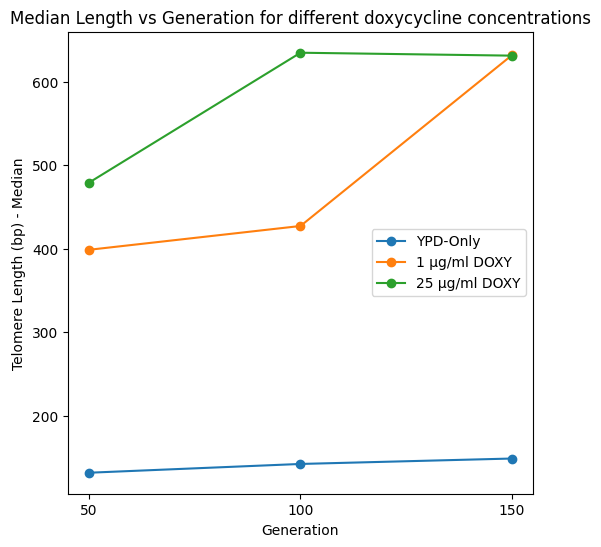

In [2]:
base_dir = "../../results/"
files_to_get = ["G50_YPD-Only/G50_YPD-Only_Filtred_Results.csv", "G100_YPD-Only/G100_YPD-Only_Filtred_Results.csv", "G150_YPD-Only/G150_YPD-Only_Filtred_Results.csv", "G50_1_DOXY/G50_1_DOXY_Filtred_Results.csv", "G100_1_DOXY/G100_1_DOXY_Filtred_Results.csv", "G150_1_DOXY/G150_1_DOXY_Filtred_Results.csv", 
"G50_25_DOXY/G50_25_DOXY_Filtred_Results.csv", "G100_25_DOXY/G100_25_DOXY_Filtred_Results.csv", "G150_25_DOXY/G150_25_DOXY_Filtred_Results.csv"]

full_paths = [os.path.join(base_dir, f) for f in files_to_get]

YPD_data_list = []
DOXY1_data_list = []
DOXY25_data_list = []

for index, path in enumerate(full_paths):
    if index < 3:
        data = pd.read_csv(path, sep="\t")
        YPD_data_list.append(data["len"].median())
    elif index < 6:
        data = pd.read_csv(path, sep="\t")
        DOXY1_data_list.append(data["len"].median())
    else:
        data = pd.read_csv(path, sep="\t")
        DOXY25_data_list.append(data["len"].median())

plt.figure(figsize=(6, 6))
plt.plot([50, 100, 150], YPD_data_list, marker='o', label='YPD-Only')
plt.plot([50, 100, 150], DOXY1_data_list, marker='o', label='1 µg/ml DOXY')
plt.plot([50, 100, 150], DOXY25_data_list, marker='o', label='25 µg/ml DOXY')
plt.xlabel('Generation')
plt.xticks([50, 100, 150])
plt.ylabel('Telomere Length (bp) - Median')
plt.title('Median Length vs Generation for different doxycycline concentrations')
plt.legend()
#plt.savefig("donatelo4_median_length.png", dpi=450)

In [16]:
print(YPD_data_list)
print(DOXY1_data_list)
print(DOXY25_data_list)

[np.float64(131.5), np.float64(142.0), np.float64(148.5)]
[np.float64(398.5), np.float64(427.0), np.float64(631.5)]
[np.float64(479.0), np.float64(634.5), np.float64(631.0)]


In [23]:
print("YPD")
print((142-131.5)/50)
print((148.5-131.5)/100)

print("DOXY 1")
print((427-398.5)/50)
print((631.5-398.5)/100)

print("DOXY 25")
print((634-479)/50)
print((631-479)/100)

YPD
0.21
0.17
DOXY 1
0.57
2.33
DOXY 25
3.1
1.52


In [ ]:
base_dir = "../../results/"
files_to_get = ["G600_0.01_DOXY_Rep1/G600_0.01_DOXY_Rep1_Filtred_Results.csv", 
"G600_0.01_DOXY_Rep2/G600_0.01_DOXY_Rep2_Filtred_Results.csv", 
"G600_0.01_DOXY_Rep3/G600_0.01_DOXY_Rep3_Filtred_Results.csv", 
"G600_0.1_DOXY_Rep1/G600_0.1_DOXY_Rep1_Filtred_Results.csv", 
"G600_0.1_DOXY_Rep2/G600_0.1_DOXY_Rep2_Filtred_Results.csv", 
"G600_0.1_DOXY_Rep3/G600_0.1_DOXY_Rep3_Filtred_Results.csv", 
"G600_25_DOXY_Rep1/G600_25_DOXY_Rep1_Filtred_Results.csv", 
"G600_25_DOXY_Rep2/G600_25_DOXY_Rep2_Filtred_Results.csv", 
"G600_25_DOXY_Rep3/G600_25_DOXY_Rep3_Filtred_Results.csv", 
"G600_YPD-Only_Rep1/G600_YPD-Only_Rep1_Filtred_Results.csv", 
"G600_YPD-Only_Rep2/G600_YPD-Only_Rep2_Filtred_Results.csv", 
"G600_YPD-Only_Rep3/G600_YPD-Only_Rep3_Filtred_Results.csv"]

full_paths = [os.path.join(base_dir, f) for f in files_to_get]

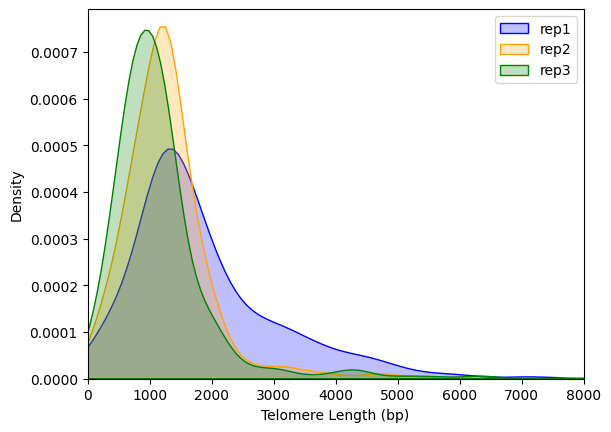

In [49]:
data_001_DOXY_rep1 = pd.read_csv(full_paths[6], sep="\t")
data_001_DOXY_rep2 = pd.read_csv(full_paths[7], sep="\t")
data_001_DOXY_rep3 = pd.read_csv(full_paths[8], sep="\t")
sns.kdeplot(data_001_DOXY_rep1["len"], fill=True, color="blue", label="rep1")
sns.kdeplot(data_001_DOXY_rep2["len"], fill=True, color="orange", label="rep2")
sns.kdeplot(data_001_DOXY_rep3["len"], fill=True, color="green", label="rep3")
plt.xlabel('Telomere Length (bp)')
plt.xlim(0, 8000)
plt.ylabel('Density')
plt.legend()
plt.show()

In [53]:
print(data_001_DOXY_rep1["len"].median())
print(data_001_DOXY_rep2["len"].median())
print(data_001_DOXY_rep3["len"].median())

1526.5
1214.0
1020.0


In [27]:
base_dir = "../../results/"
files_to_get = [
    "Y2B1115/Y2B1115_Filtred_Results.csv",
    "OS13342/OS13342_Filtred_Results.csv",
    "AG0/AG0_Filtred_Results.csv",
    "AG150/AG150_Filtred_Results.csv",
    "BG0/BG0_Filtred_Results.csv",
    "BG150/BG150_Filtred_Results.csv",
    "CG0/CG0_Filtred_Results.csv",
    "CG150/CG150_Filtred_Results.csv"
]

full_paths = [os.path.join(base_dir, f) for f in files_to_get]

all_lengths = {}

for path in full_paths:
    temp_data = pd.read_csv(path, sep="\t")
    col_name = temp_data["assembly"].iloc[0].replace("_genome_ordered", "")
    all_lengths[col_name] = temp_data["len"]

data = pd.DataFrame(all_lengths)
data = data.melt(var_name="Sample", value_name="Length").dropna()

print(data)

       Sample  Length
0     Y2B1115   413.0
1     Y2B1115   380.0
2     Y2B1115   467.0
3     Y2B1115   454.0
4     Y2B1115   434.0
...       ...     ...
8060    CG150   690.0
8061    CG150  1224.0
8062    CG150  1763.0
8063    CG150  1041.0
8064    CG150  2844.0

[4374 rows x 2 columns]


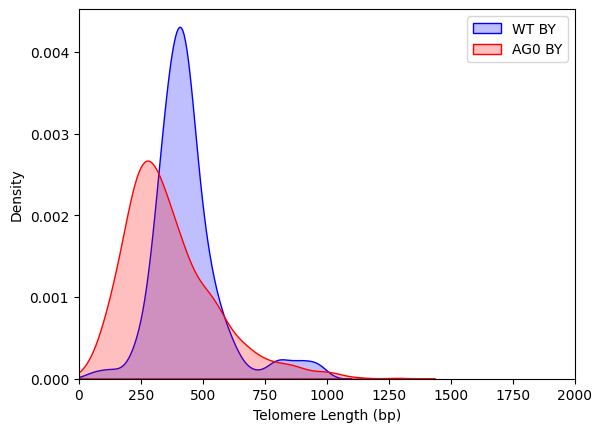

In [32]:
sns.kdeplot(data["Length"].loc[data["Sample"] == "Y2B1115"], fill=True, color="blue", label="WT BY")
sns.kdeplot(data["Length"].loc[data["Sample"] == "AG0"], fill=True, color="red", label="AG0 BY")
#sns.kdeplot(data["Length"].loc[data["Sample"] == "BG0"], fill=True, color="yellow", label="BG0 BY")
#sns.kdeplot(data["Length"].loc[data["Sample"] == "CG0"], fill=True, color="green", label="CG0 BY")

plt.xlabel('Telomere Length (bp)')
plt.xlim(0, 2000)
plt.ylabel('Density')
plt.legend()
plt.show()

levy distribution

stable distribution (not gaussian)

# Boxplot

## Donatelo 1

In [3]:
base_dir = "../../results/"
files_to_get = [
    "Y2B1115/Y2B1115_Filtred_Results.csv",
    "OS13342/OS13342_Filtred_Results.csv",
    "Y2B1394/Y2B1394_Filtred_Results.csv", 
    "Y2B1397/Y2B1397_Filtred_Results.csv", 
    "A10/A10_Filtred_Results.csv", 
    "B10/B10_Filtred_Results.csv", 
    "G10/G10_Filtred_Results.csv", 
    "H10/H10_Filtred_Results.csv", 
]

full_paths = [os.path.join(base_dir, f) for f in files_to_get]

all_lengths = {}

for path in full_paths:
    temp_data = pd.read_csv(path, sep="\t")
    col_name = temp_data["assembly"].iloc[0].replace("_genome_ordered", "")
    all_lengths[col_name] = temp_data["len"]

data = pd.DataFrame(all_lengths)
data = data.melt(var_name="Sample", value_name="Length").dropna()

print(data)

        Sample  Length
0      Y2B1115   413.0
1      Y2B1115   380.0
2      Y2B1115   467.0
3      Y2B1115   454.0
4      Y2B1115   434.0
...        ...     ...
13275      H10   151.0
13276      H10   220.0
13277      H10   204.0
13278      H10   193.0
13279      H10   223.0

[7036 rows x 2 columns]


In [4]:
group_map = {
    'A10': 'BY',
    'B10': 'CAS',
    'G10': 'BY',
    'H10': 'CAS',
    'Y2B1115': 'BY',
    'Y2B1394': 'BY',
    'Y2B1397': 'CAS',
    'OS13342': 'CAS'
}

gen_map = {
    'A10': 'G50',
    'B10': 'G50',
    'G10': 'G300',
    'H10': 'G300',
    'Y2B1115': 'WT',
    'Y2B1394': 'G0',
    'Y2B1397': 'G0',
    'OS13342': 'WT'
}

data['Strains'] = data['Sample'].map(group_map)
data["generation"] = data['Sample'].map(gen_map)
data.head()

,Sample,Length,Strains,generation
0,Y2B1115,413.0,BY,WT
1,Y2B1115,380.0,BY,WT
2,Y2B1115,467.0,BY,WT
3,Y2B1115,454.0,BY,WT
4,Y2B1115,434.0,BY,WT


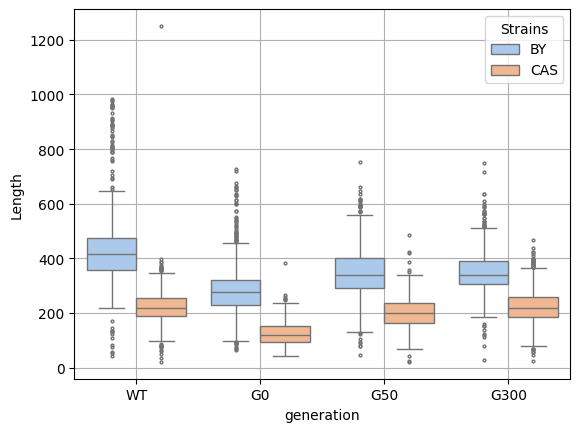

In [5]:
sns.boxplot(data=data, x="generation", y="Length", hue="Strains", palette="pastel", fliersize=2)
plt.grid()
#plt.savefig("donatelo1_tel_len.png", dpi=450)

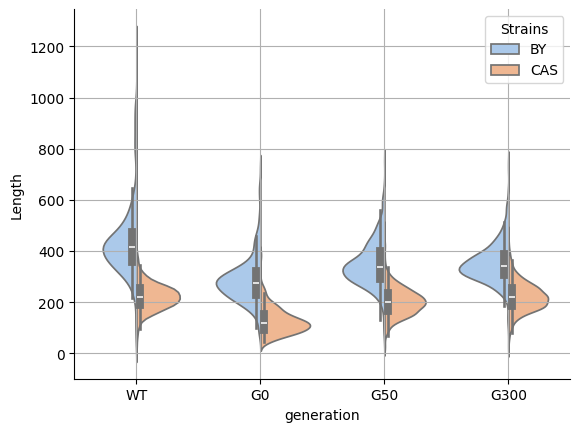

In [6]:
ax = sns.violinplot(data=data, 
                    x="generation", 
                    y="Length", 
                    hue="Strains", 
                    split=True, 
                    inner="box",
                    palette="pastel")

sns.despine()
plt.grid()

In [64]:
data.groupby("Sample")["Length"].median()

Sample
A10        339.0
B10        199.5
G10        341.0
H10        219.0
OS13342    220.0
Y2B1115    416.0
Y2B1394    277.0
Y2B1397    118.0
Name: Length, dtype: float64

In [9]:
temp_data.columns

Index(['assembly', 'chrom', 'chrom_side', 'chrom_type', 'chrom_start',
       'chrom_end', 'chrom_len', 'chrom_size', 'strain', '#reads', 'read',
       'side', 'type', 'start', 'end', 'len', 'read_size_trim', 'MAPQ',
       'FLAG'],
      dtype='object')

/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the stripplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/home/lsenez/min

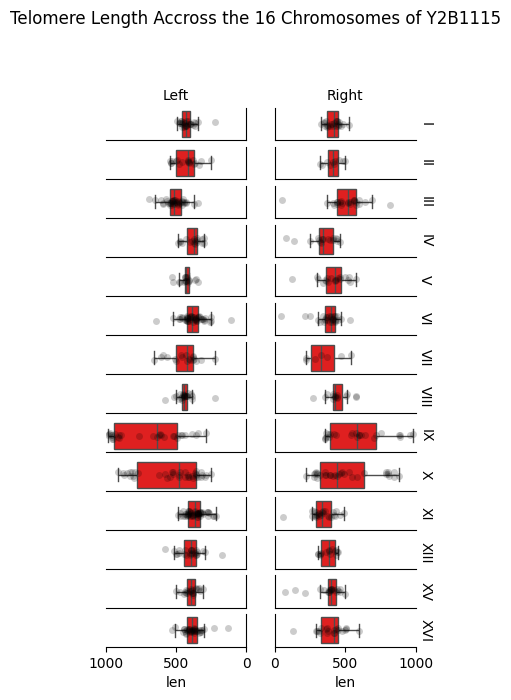

In [ ]:
all_lengths = {}
data = pd.DataFrame(all_lengths)

for path in full_paths:
    temp_data = pd.read_csv(path, sep="\t")
    temp_data["assembly"] = temp_data["assembly"].iloc[0].replace("_genome_ordered", "")
    data = pd.concat([data, temp_data[["assembly", "len", "chrom", "side"]]], ignore_index=True)

data['chrom'] = data['chrom'].str.replace('chr', '', regex=False)

for assemb in data["assembly"].unique():
    g = sns.FacetGrid(data.loc[data["assembly"] == assemb], row="chrom", col="side", margin_titles=True, height=0.5, aspect=4, sharex=False)

    g.figure.suptitle("Telomere Length Accross the 16 Chromosomes of " + assemb, y=1.02)

    g.map(sns.stripplot, "len", color="black", alpha=0.2, jitter=True)
    g.map(sns.boxplot, "len", color="red", fliersize=0)

    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    
    for ax in g.axes.flat:
        ax.set_ylabel('')
        ax.set_xlim(0, 1000)
        if not ax.get_subplotspec().is_last_row():
            ax.tick_params(labelbottom=False, bottom=False)

    for i, ax in enumerate(g.axes[:, 0]):
        ax.invert_xaxis()
        ax.yaxis.set_label_position("right")
        ax.set_yticks([])
        ax.yaxis.tick_right()
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(True)


    plt.show()


## Donatelo 2

In [46]:
base_dir = "../../results/"
files_to_get = [
    "AG0/AG0_Filtred_Results.csv",
    "AG50/AG50_Filtred_Results.csv",
    "AG150/AG150_Filtred_Results.csv",
    "BG0/BG0_Filtred_Results.csv",
    "BG50/BG50_Filtred_Results.csv",
    "BG150/BG150_Filtred_Results.csv",
    "CG0/CG0_Filtred_Results.csv",
    "CG50/CG50_Filtred_Results.csv",
    "CG150/CG150_Filtred_Results.csv"
]

full_paths = [os.path.join(base_dir, f) for f in files_to_get]

all_lengths = {}

for path in full_paths:
    temp_data = pd.read_csv(path, sep="\t")
    col_name = temp_data["assembly"].iloc[0].replace("_genome_ordered", "")
    all_lengths[col_name] = temp_data["len"]

data = pd.DataFrame(all_lengths)
data = data.melt(var_name="Sample", value_name="Length").dropna()

print(data)

     Sample  Length
0       AG0   219.0
1       AG0   419.0
2       AG0   300.0
3       AG0   657.0
4       AG0   524.0
...     ...     ...
6400  CG150   690.0
6401  CG150  1224.0
6402  CG150  1763.0
6403  CG150  1041.0
6404  CG150  2844.0

[4115 rows x 2 columns]


In [47]:
group_map = {
    'AG0': 'AG',
    'AG50': 'AG',
    'AG150': 'AG',
    'BG0': 'BG',
    'BG50': 'BG',
    'BG150': 'BG',
    'CG0': 'CG',
    'CG50': 'CG',
    'CG150': 'CG'
}

data['Group'] = data['Sample'].map(group_map)
data.head()

,Sample,Length,Group
0,AG0,219.0,AG
1,AG0,419.0,AG
2,AG0,300.0,AG
3,AG0,657.0,AG
4,AG0,524.0,AG


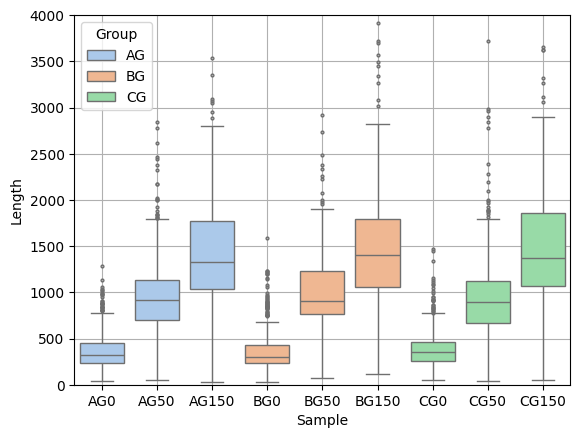

In [49]:
sns.boxplot(data=data, x="Sample", y="Length", hue="Group", palette="pastel", fliersize=2)
plt.ylim(0, 4000)
plt.grid()
plt.savefig("donatelo2_tel_len.png", dpi=450)

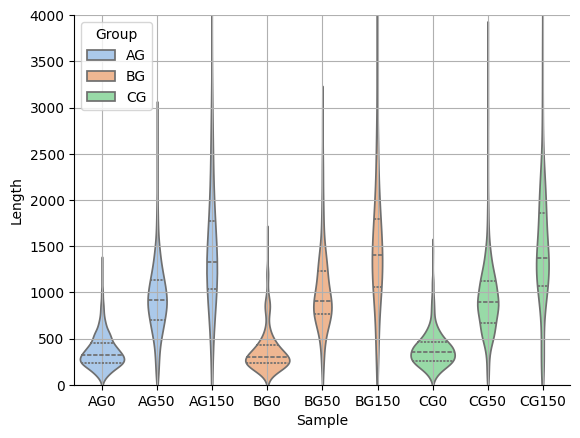

In [13]:
ax = sns.violinplot(data=data, 
                    x="Sample", 
                    y="Length", 
                    hue="Group", 
                    inner="quart",
                    palette="pastel")

sns.despine()
plt.ylim(0, 4000)
plt.grid()

## Donatelo 3

In [1]:
print("youhou")

youhou


## Donatelo 4

In [2]:
base_dir = "../../results/"
files_to_get = [
    "G50_YPD-Only/G50_YPD-Only_Filtred_Results.csv", 
    "G100_YPD-Only/G100_YPD-Only_Filtred_Results.csv", 
    "G150_YPD-Only/G150_YPD-Only_Filtred_Results.csv", 
    "G50_1_DOXY/G50_1_DOXY_Filtred_Results.csv", 
    "G100_1_DOXY/G100_1_DOXY_Filtred_Results.csv", 
    "G150_1_DOXY/G150_1_DOXY_Filtred_Results.csv", 
    "G50_25_DOXY/G50_25_DOXY_Filtred_Results.csv", 
    "G100_25_DOXY/G100_25_DOXY_Filtred_Results.csv", 
    "G150_25_DOXY/G150_25_DOXY_Filtred_Results.csv"
]

full_paths = [os.path.join(base_dir, f) for f in files_to_get]

all_lengths = {}

for path in full_paths:
    temp_data = pd.read_csv(path, sep="\t")
    col_name = temp_data["assembly"].iloc[0].replace("_genome_ordered", "")
    all_lengths[col_name] = temp_data["len"]

data = pd.DataFrame(all_lengths)
data = data.melt(var_name="Sample", value_name="Length").dropna()

print(data)

            Sample  Length
0     G50_YPD-Only   194.0
1     G50_YPD-Only   150.0
2     G50_YPD-Only   152.0
3     G50_YPD-Only    87.0
4     G50_YPD-Only    47.0
...            ...     ...
2516  G150_25_DOXY   481.0
2517  G150_25_DOXY   402.0
2518  G150_25_DOXY   275.0
2519  G150_25_DOXY   401.0
2520  G150_25_DOXY   997.0

[1810 rows x 2 columns]


In [51]:
group_map = {
    'G50_YPD-Only': 'YPD-Only',
    'G100_YPD-Only': 'YPD-Only',
    'G150_YPD-Only': 'YPD-Only',
    'G50_1_DOXY': '1 µg/ml DOXY',
    'G100_1_DOXY': '1 µg/ml DOXY',
    'G150_1_DOXY': '1 µg/ml DOXY',
    'G50_25_DOXY': '25 µg/ml DOXY',
    'G100_25_DOXY': '25 µg/ml DOXY',
    'G150_25_DOXY': '25 µg/ml DOXY'
}

gen_map = {
    'G50_YPD-Only': 'G50',
    'G100_YPD-Only': 'G100',
    'G150_YPD-Only': 'G150',
    'G50_1_DOXY': 'G50',
    'G100_1_DOXY': 'G100',
    'G150_1_DOXY': 'G150',
    'G50_25_DOXY': 'G50',
    'G100_25_DOXY': 'G100',
    'G150_25_DOXY': 'G150'
}

data['Group'] = data['Sample'].map(group_map)
data["generation"] = data['Sample'].map(gen_map)
data.head()

,Sample,Length,Group,generation
0,G50_YPD-Only,194.0,YPD-Only,G50
1,G50_YPD-Only,150.0,YPD-Only,G50
2,G50_YPD-Only,152.0,YPD-Only,G50
3,G50_YPD-Only,87.0,YPD-Only,G50
4,G50_YPD-Only,47.0,YPD-Only,G50


/tmp/ipykernel_168097/3375668794.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


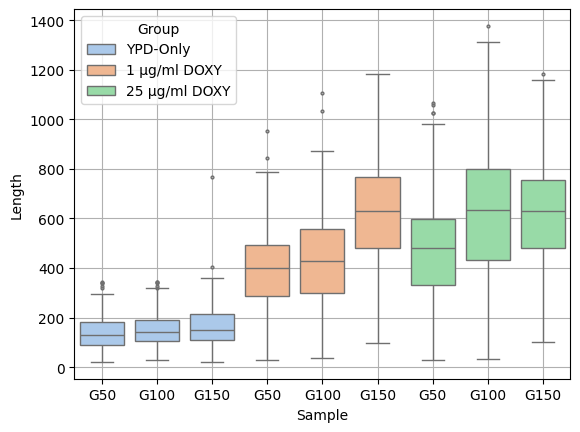

In [53]:
ax = sns.boxplot(data=data, x="Sample", y="Length", hue="Group", palette="pastel", fliersize=2)
new_labels = [label.get_text().split('_')[0] for label in ax.get_xticklabels()]
ax.set_xticklabels(new_labels)
plt.grid()
plt.savefig("donatelo3_tel_len.png", dpi=450)

/tmp/ipykernel_168097/535080251.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


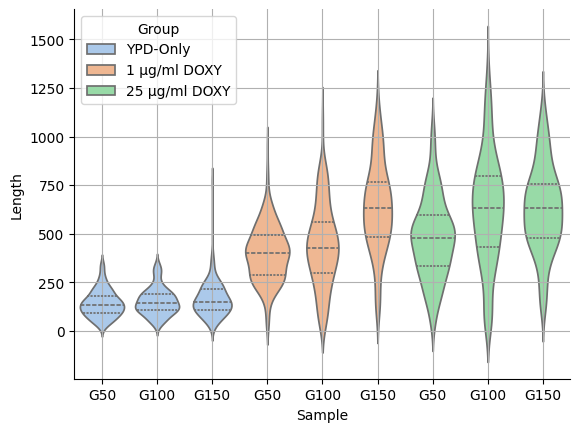

In [25]:
ax = sns.violinplot(data=data, 
                    x="Sample", 
                    y="Length", 
                    hue="Group", 
                    inner="quart",
                    palette="pastel")
new_labels = [label.get_text().split('_')[0] for label in ax.get_xticklabels()]
ax.set_xticklabels(new_labels)
sns.despine()
plt.grid()

/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the stripplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/home/lsenez/min

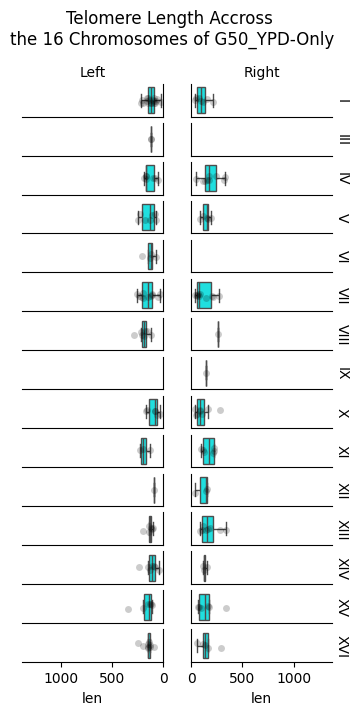

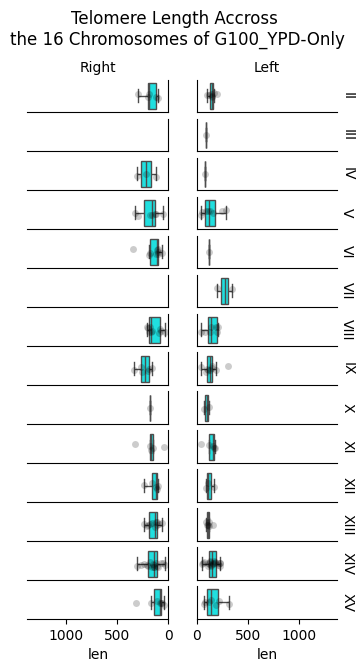

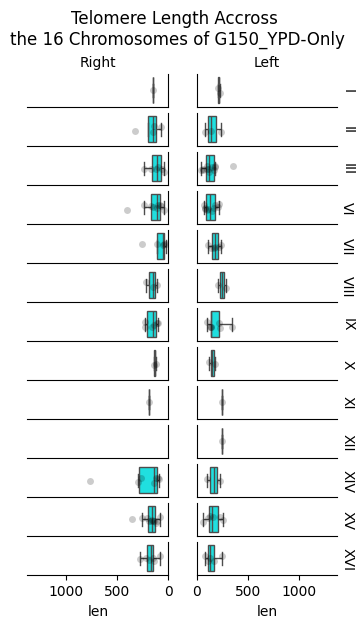

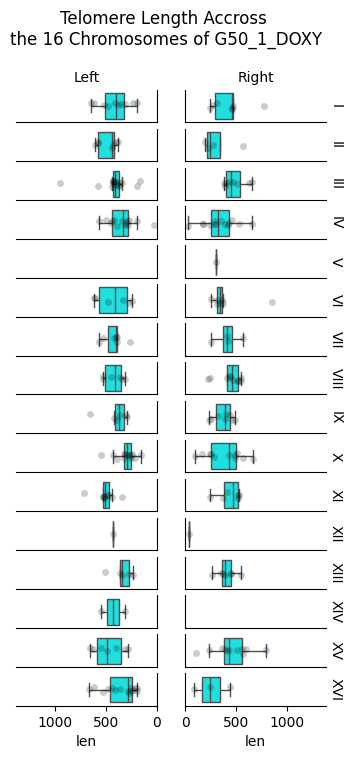

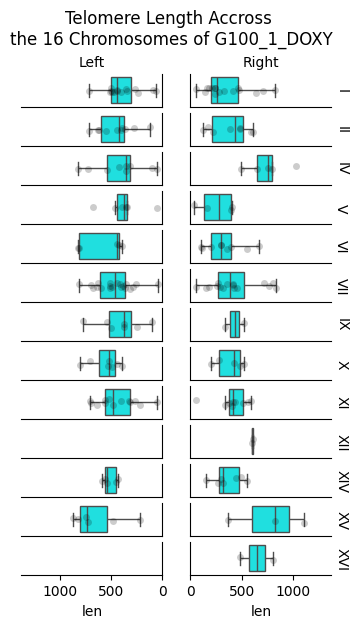

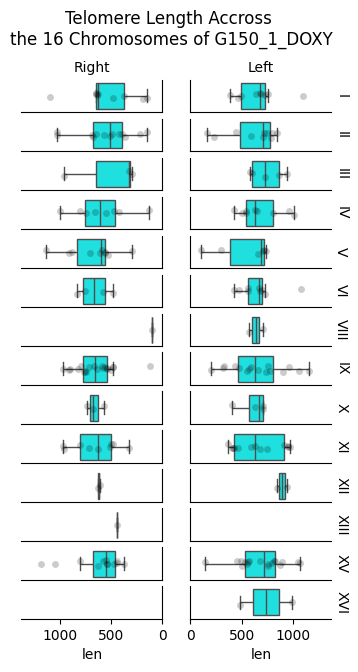

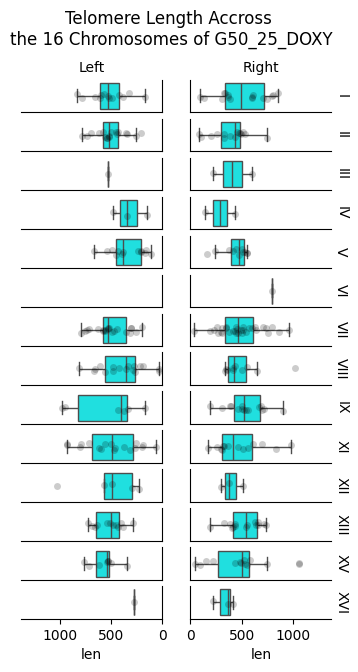

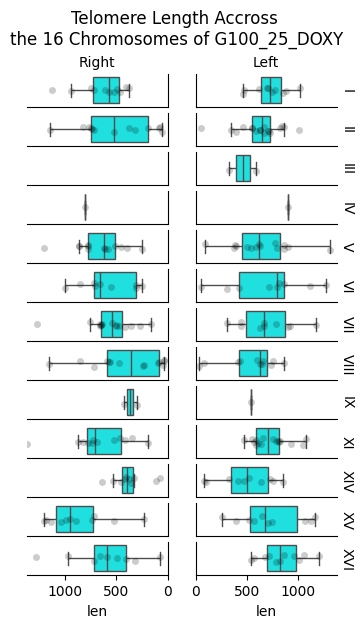

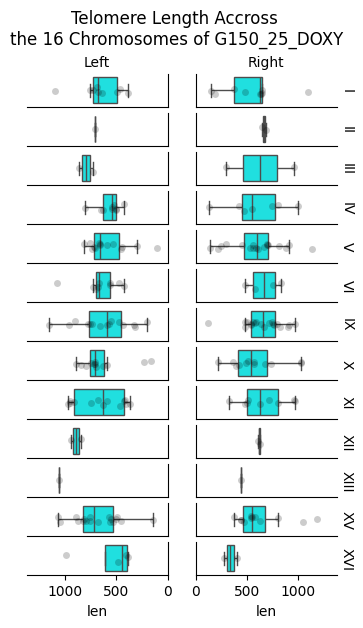

In [7]:
all_lengths = {}
data = pd.DataFrame(all_lengths)

for path in full_paths:
    temp_data = pd.read_csv(path, sep="\t")
    temp_data["assembly"] = temp_data["assembly"].iloc[0].replace("_genome_ordered", "")
    data = pd.concat([data, temp_data[["assembly", "len", "chrom", "side"]]], ignore_index=True)

data['chrom'] = data['chrom'].str.replace('chr', '', regex=False)

for assemb in data["assembly"].unique():
    g = sns.FacetGrid(data.loc[data["assembly"] == assemb], row="chrom", col="side", margin_titles=True, height=0.5, aspect=4, sharex=False)

    g.figure.suptitle("Telomere Length Accross \nthe 16 Chromosomes of " + assemb)

    g.map(sns.stripplot, "len", color="black", alpha=0.2, jitter=True)
    g.map(sns.boxplot, "len", color="cyan", fliersize=0)

    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    
    for ax in g.axes.flat:
        ax.set_ylabel('')
        ax.set_xlim(0, data["len"].max())
        if not ax.get_subplotspec().is_last_row():
            ax.tick_params(labelbottom=False, bottom=False)

    for i, ax in enumerate(g.axes[:, 0]):
        ax.invert_xaxis()
        ax.yaxis.set_label_position("right")
        ax.set_yticks([])
        ax.yaxis.tick_right()
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(True)


    plt.savefig(assemb + "_telomere_length_by_chromosome.png", dpi=450)


## Donatelo 5a

In [8]:
base_dir = "../../results/"
files_to_get = [
    "G600_YPD-Only_Rep1/G600_YPD-Only_Rep1_Filtred_Results.csv", 
    "G600_YPD-Only_Rep2/G600_YPD-Only_Rep2_Filtred_Results.csv", 
    "G600_YPD-Only_Rep3/G600_YPD-Only_Rep3_Filtred_Results.csv",
    "G600_0.01_DOXY_Rep1/G600_0.01_DOXY_Rep1_Filtred_Results.csv", 
    "G600_0.01_DOXY_Rep2/G600_0.01_DOXY_Rep2_Filtred_Results.csv", 
    "G600_0.01_DOXY_Rep3/G600_0.01_DOXY_Rep3_Filtred_Results.csv", 
    "G600_0.1_DOXY_Rep1/G600_0.1_DOXY_Rep1_Filtred_Results.csv", 
    "G600_0.1_DOXY_Rep2/G600_0.1_DOXY_Rep2_Filtred_Results.csv", 
    "G600_0.1_DOXY_Rep3/G600_0.1_DOXY_Rep3_Filtred_Results.csv", 
    "G600_25_DOXY_Rep1/G600_25_DOXY_Rep1_Filtred_Results.csv", 
    "G600_25_DOXY_Rep2/G600_25_DOXY_Rep2_Filtred_Results.csv", 
    "G600_25_DOXY_Rep3/G600_25_DOXY_Rep3_Filtred_Results.csv"

]

full_paths = [os.path.join(base_dir, f) for f in files_to_get]

all_lengths = {}

for path in full_paths:
    temp_data = pd.read_csv(path, sep="\t")
    col_name = temp_data["assembly"].iloc[0].replace("_genome_ordered", "")
    all_lengths[col_name] = temp_data["len"]

data = pd.DataFrame(all_lengths)
data = data.melt(var_name="Sample", value_name="Length").dropna()

print(data)

                   Sample  Length
0      G600_YPD-Only_Rep1  2103.0
1      G600_YPD-Only_Rep1  2669.0
2      G600_YPD-Only_Rep1  3095.0
3      G600_YPD-Only_Rep1  1809.0
4      G600_YPD-Only_Rep1  1992.0
...                   ...     ...
14715   G600_25_DOXY_Rep3   974.0
14716   G600_25_DOXY_Rep3  1019.0
14717   G600_25_DOXY_Rep3   587.0
14718   G600_25_DOXY_Rep3   146.0
14719   G600_25_DOXY_Rep3   561.0

[10124 rows x 2 columns]


In [56]:
group_map = {
    'G600_0.01_DOXY_Rep1': '0.01 µg/ml DOXY',
    'G600_0.01_DOXY_Rep2': '0.01 µg/ml DOXY',
    'G600_0.01_DOXY_Rep3': '0.01 µg/ml DOXY',
    'G600_0.1_DOXY_Rep1': '0.1 µg/ml DOXY',
    'G600_0.1_DOXY_Rep2': '0.1 µg/ml DOXY',
    'G600_0.1_DOXY_Rep3': '0.1 µg/ml DOXY',
    'G600_25_DOXY_Rep1': '25 µg/ml DOXY',
    'G600_25_DOXY_Rep2': '25 µg/ml DOXY',
    'G600_25_DOXY_Rep3': '25 µg/ml DOXY',
    'G600_YPD-Only_Rep1': 'YPD-Only',
    'G600_YPD-Only_Rep2': 'YPD-Only',
    'G600_YPD-Only_Rep3': 'YPD-Only'
}


data['Group'] = data['Sample'].map(group_map)
data.head()

,Sample,Length,Group
0,G600_YPD-Only_Rep1,2103.0,YPD-Only
1,G600_YPD-Only_Rep1,2669.0,YPD-Only
2,G600_YPD-Only_Rep1,3095.0,YPD-Only
3,G600_YPD-Only_Rep1,1809.0,YPD-Only
4,G600_YPD-Only_Rep1,1992.0,YPD-Only


/tmp/ipykernel_168097/175832709.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


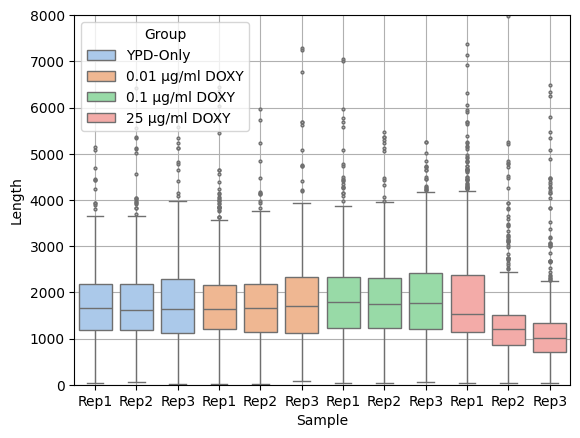

In [59]:
ax = sns.boxplot(data=data, x="Sample", y="Length", hue="Group", palette="pastel", fliersize=2)
new_labels = [label.get_text().split('_')[-1] for label in ax.get_xticklabels()]
ax.set_xticklabels(new_labels)
plt.ylim(0, 8000)
plt.grid()
plt.savefig("donatelo5a_tel_len.png", dpi=450)

In [41]:
data.groupby("Sample")["Length"].median()

Sample
G600_0.01_DOXY_Rep1    1633.0
G600_0.01_DOXY_Rep2    1651.5
G600_0.01_DOXY_Rep3    1710.0
G600_0.1_DOXY_Rep1     1780.0
G600_0.1_DOXY_Rep2     1752.0
G600_0.1_DOXY_Rep3     1770.0
G600_25_DOXY_Rep1      1526.5
G600_25_DOXY_Rep2      1214.0
G600_25_DOXY_Rep3      1020.0
G600_YPD-Only_Rep1     1668.0
G600_YPD-Only_Rep2     1618.0
G600_YPD-Only_Rep3     1638.0
Name: Length, dtype: float64

/tmp/ipykernel_168097/535080251.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


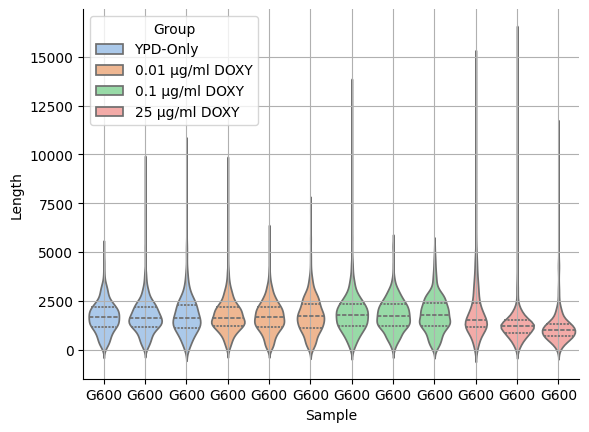

In [39]:
ax = sns.violinplot(data=data, 
                    x="Sample", 
                    y="Length", 
                    hue="Group", 
                    inner="quart",
                    palette="pastel")
new_labels = [label.get_text().split('_')[0] for label in ax.get_xticklabels()]
ax.set_xticklabels(new_labels)
sns.despine()
plt.grid()

/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the stripplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/home/lsenez/min

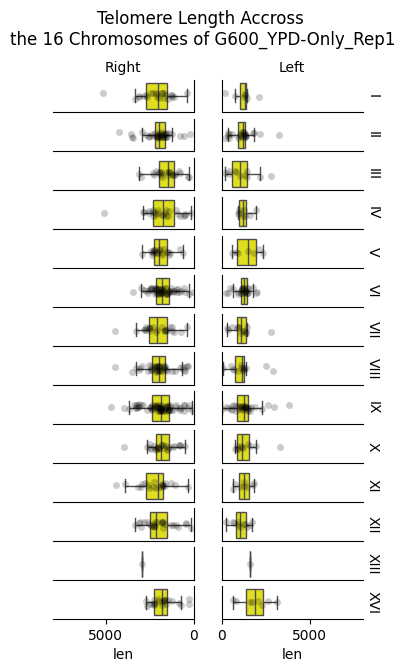

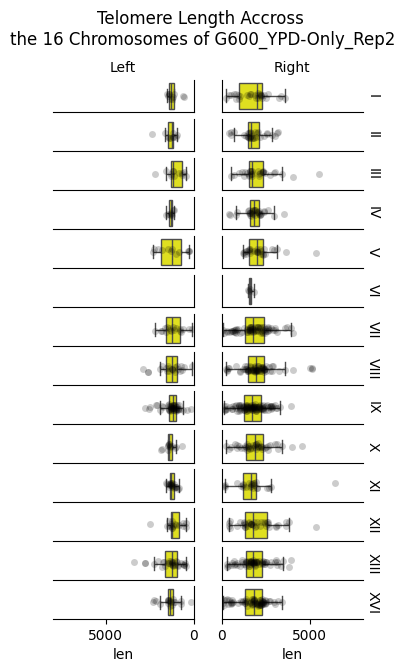

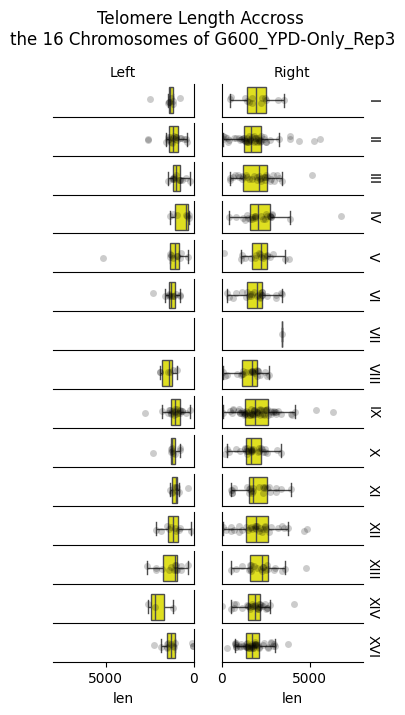

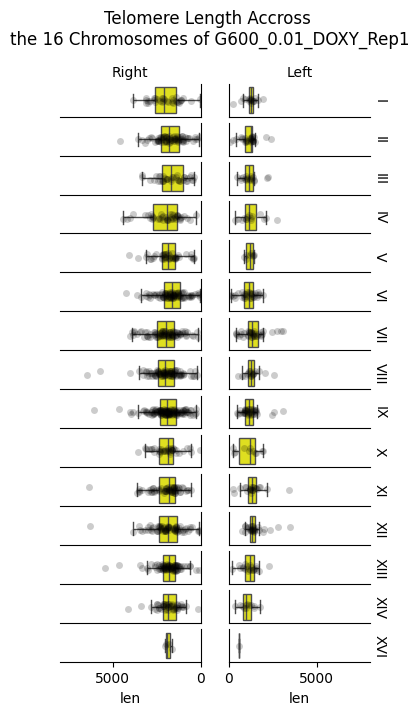

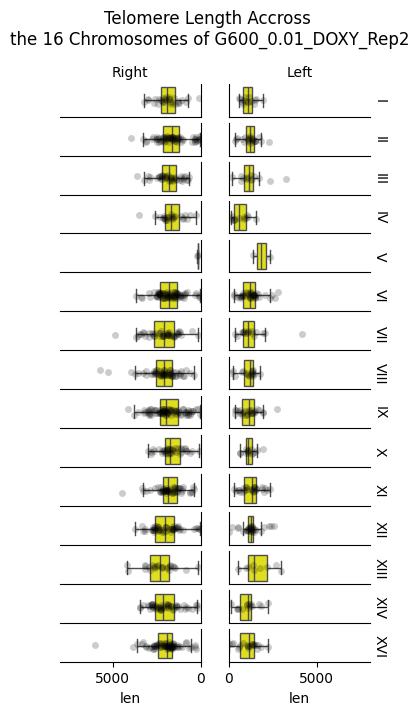

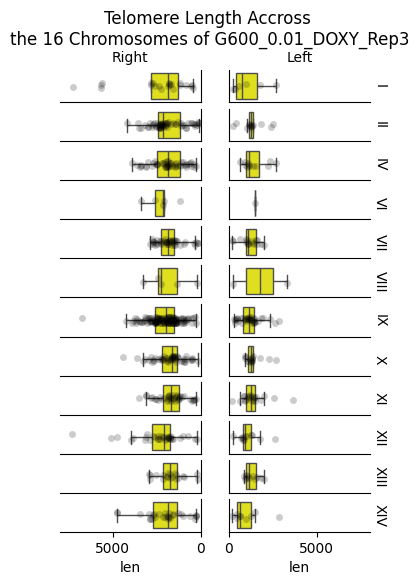

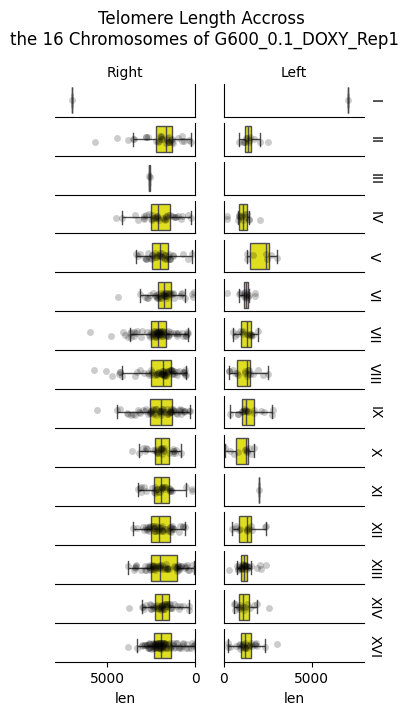

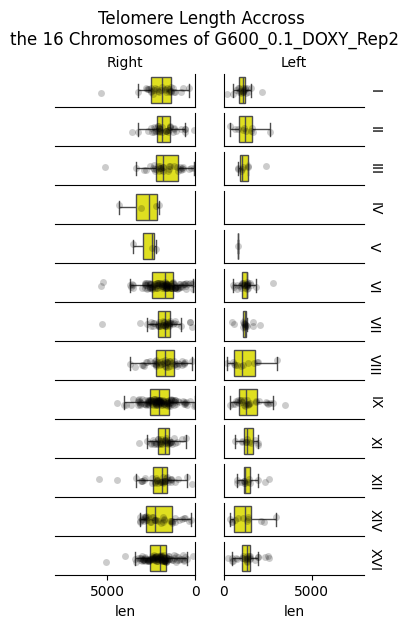

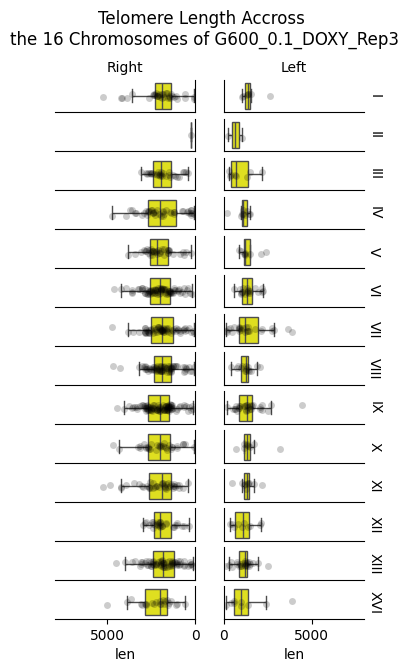

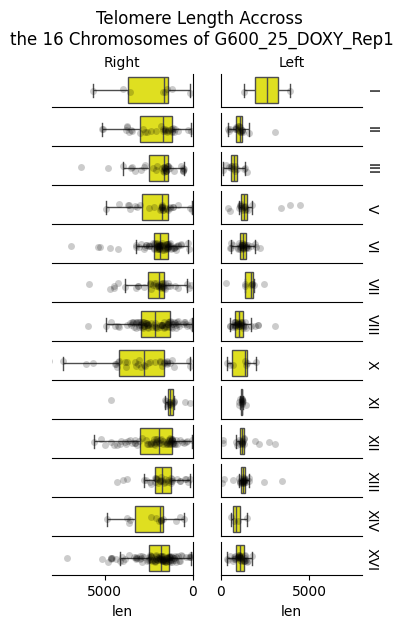

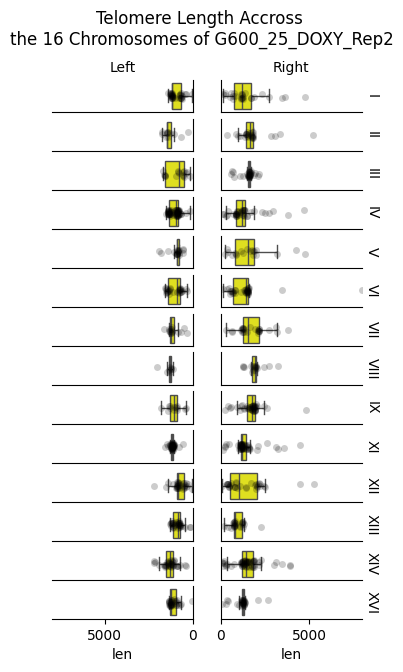

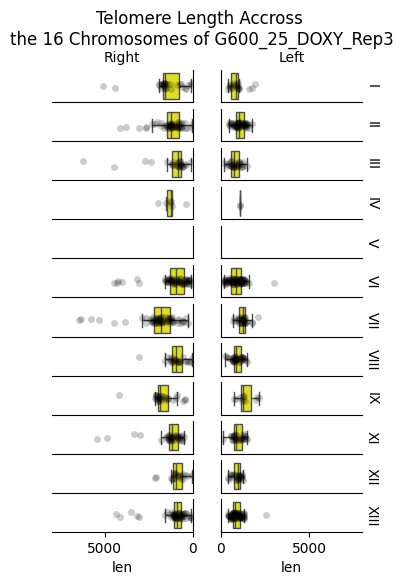

In [14]:
all_lengths = {}
data = pd.DataFrame(all_lengths)

for path in full_paths:
    temp_data = pd.read_csv(path, sep="\t")
    temp_data["assembly"] = temp_data["assembly"].iloc[0].replace("_genome_ordered", "")
    data = pd.concat([data, temp_data[["assembly", "len", "chrom", "side"]]], ignore_index=True)

data['chrom'] = data['chrom'].str.replace('chr', '', regex=False)

for assemb in data["assembly"].unique():
    g = sns.FacetGrid(data.loc[data["assembly"] == assemb], row="chrom", col="side", margin_titles=True, height=0.5, aspect=4, sharex=False)

    g.figure.suptitle("Telomere Length Accross \nthe 16 Chromosomes of " + assemb)

    g.map(sns.stripplot, "len", color="black", alpha=0.2, jitter=True)
    g.map(sns.boxplot, "len", color="yellow", fliersize=0)

    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    
    for ax in g.axes.flat:
        ax.set_ylabel('')
        ax.set_xlim(0, 8000)
        if not ax.get_subplotspec().is_last_row():
            ax.tick_params(labelbottom=False, bottom=False)

    for i, ax in enumerate(g.axes[:, 0]):
        ax.invert_xaxis()
        ax.yaxis.set_label_position("right")
        ax.set_yticks([])
        ax.yaxis.tick_right()
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(True)


    plt.savefig(assemb + "_telomere_length_by_chromosome.png", dpi=450)


In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
base_dir = "../../results/"
files_to_get = [
    "G600_CAS_YPD-Only_Rep1/G600_CAS_YPD-Only_Rep1_Filtred_Results.csv",
    "G600_CAS_YPD-Only_Rep2/G600_CAS_YPD-Only_Rep2_Filtred_Results.csv",
    "G600_CAS_0.01_DOXY_Rep1/G600_CAS_0.01_DOXY_Rep1_Filtred_Results.csv",
    "G600_CAS_0.01_DOXY_Rep2/G600_CAS_0.01_DOXY_Rep2_Filtred_Results.csv",
    "G600_CAS_0.1_DOXY_Rep1/G600_CAS_0.1_DOXY_Rep1_Filtred_Results.csv",
    "G600_CAS_0.1_DOXY_Rep2/G600_CAS_0.1_DOXY_Rep2_Filtred_Results.csv",
    "G600_CAS_25_DOXY_Rep1/G600_CAS_25_DOXY_Rep1_Filtred_Results.csv",
    "G600_CAS_25_DOXY_Rep2/G600_CAS_25_DOXY_Rep2_Filtred_Results.csv"
]

full_paths = [os.path.join(base_dir, f) for f in files_to_get]

all_lengths = {}

for path in full_paths:
    temp_data = pd.read_csv(path, sep="\t")
    col_name = temp_data["assembly"].iloc[0].replace("_genome_ordered", "")
    all_lengths[col_name] = temp_data["len"]

data = pd.DataFrame(all_lengths)
data = data.melt(var_name="Sample", value_name="Length").dropna()

print(data)

                      Sample  Length
0     G600_CAS_YPD-Only_Rep1   867.0
1     G600_CAS_YPD-Only_Rep1   458.0
2     G600_CAS_YPD-Only_Rep1   140.0
3     G600_CAS_YPD-Only_Rep1   865.0
4     G600_CAS_YPD-Only_Rep1   667.0
...                      ...     ...
8211   G600_CAS_25_DOXY_Rep2  3301.0
8212   G600_CAS_25_DOXY_Rep2  1719.0
8213   G600_CAS_25_DOXY_Rep2  3210.0
8214   G600_CAS_25_DOXY_Rep2   619.0
8215   G600_CAS_25_DOXY_Rep2  3498.0

[5795 rows x 2 columns]


In [5]:
group_map = {
    'G600_CAS_YPD-Only_Rep1': 'YPD-Only',
    'G600_CAS_YPD-Only_Rep2': 'YPD-Only',
    'G600_CAS_0.01_DOXY_Rep1': '0.01 µg/ml DOXY',
    'G600_CAS_0.01_DOXY_Rep2': '0.01 µg/ml DOXY',
    'G600_CAS_0.1_DOXY_Rep1': '0.1 µg/ml DOXY',
    'G600_CAS_0.1_DOXY_Rep2': '0.1 µg/ml DOXY',
    'G600_CAS_25_DOXY_Rep1': '25 µg/ml DOXY',
    'G600_CAS_25_DOXY_Rep2': '25 µg/ml DOXY'
}


data['Group'] = data['Sample'].map(group_map)
data.head()

,Sample,Length,Group
0,G600_CAS_YPD-Only_Rep1,867.0,YPD-Only
1,G600_CAS_YPD-Only_Rep1,458.0,YPD-Only
2,G600_CAS_YPD-Only_Rep1,140.0,YPD-Only
3,G600_CAS_YPD-Only_Rep1,865.0,YPD-Only
4,G600_CAS_YPD-Only_Rep1,667.0,YPD-Only


In [7]:
import seaborn as sns

/tmp/ipykernel_939511/474111006.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


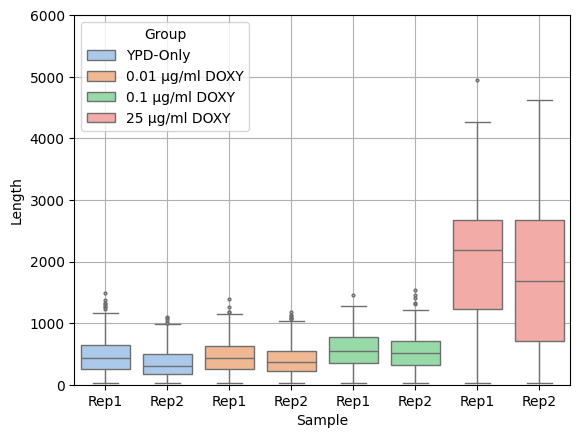

In [11]:
ax = sns.boxplot(data=data, x="Sample", y="Length", hue="Group", palette="pastel", fliersize=2)
new_labels = [label.get_text().split('_')[-1] for label in ax.get_xticklabels()]
ax.set_xticklabels(new_labels)
plt.ylim(0, 6000)
plt.grid()
plt.savefig("donatelo5b_tel_len.png", dpi=450)

In [12]:
data.groupby("Sample")["Length"].median()

Sample
G600_CAS_0.01_DOXY_Rep1     435.5
G600_CAS_0.01_DOXY_Rep2     363.0
G600_CAS_0.1_DOXY_Rep1      548.5
G600_CAS_0.1_DOXY_Rep2      522.0
G600_CAS_25_DOXY_Rep1      2192.0
G600_CAS_25_DOXY_Rep2      1685.0
G600_CAS_YPD-Only_Rep1      440.0
G600_CAS_YPD-Only_Rep2      310.0
Name: Length, dtype: float64